<div class="alert alert-block alert-success">
<b>NOTEBOOK 4 - Clustering
</div>

---
# 1 - IMPORTS

### 1.1 - SETUP PROJECT

Make sure to check `README.md` and `requirements.txt` before running any notebooks. 

In [55]:
# Import modules
import sys
import importlib
import pandas as pd
from pathlib import Path


import warnings, os
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import matplotlib.pyplot as plt

### 1.2 - DEFINE PATHS

In [56]:
# Paths
PROJECT_PATH = Path.cwd().resolve().parent
DATA_PATH = PROJECT_PATH / "data"
SRC_PATH = PROJECT_PATH / "src"
UTILS_PATH = SRC_PATH / "utilities"
PROCESSED_PATH = DATA_PATH / "processed"
OUTPUT_PATH = PROJECT_PATH / "outputs"
FIG_PATH = OUTPUT_PATH / "figures"
OUT_PATH = PROCESSED_PATH

FIG_PATH.mkdir(parents=True, exist_ok=True)

# Add src to sys.path (for package-style imports)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# Add utilities folder to sys.path (for direct import utils)
if str(UTILS_PATH) not in sys.path:
    sys.path.append(str(UTILS_PATH))

# Import with reload
try:
    import utilities.utils as utils
except ModuleNotFoundError:
    import utils

reimport = importlib.reload(utils)

### 1.3 - LOAD DATASET

In [74]:
# Load Data

# Clustering data

# Original Dataset (scaled)
full_scaled_path = PROCESSED_PATH / "01_climate_dataset_scaled.xlsx"
full_scaled = pd.read_excel(full_scaled_path, sheet_name=None)["Sheet1"]

# Imputed Dataset (scaled, no outliers)
noout_scaled_path = PROCESSED_PATH / "01_climate_dataset_scaled_noOutliers.xlsx"
noout_scaled = pd.read_excel(noout_scaled_path, sheet_name=None)["Sheet1"]

# PCA 90% Var Scaled Original
PCA_90Var_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_PCA_90Var.xlsx"
pca90_full = pd.read_excel(PCA_90Var_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 90% Var Scaled Imputed
PCA_90Var_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_PCA_90Var_noOutliers.xlsx"
pca90_noout = pd.read_excel(PCA_90Var_scaled_imputed_path, sheet_name=None)["Sheet1"]

# PCA 2D Scaled Original
PCA_2D_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_PCA_2D.xlsx"
pca2d_full = pd.read_excel(PCA_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# PCA 2D Scaled Imputed
PCA_2D_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_PCA_2D_noOutliers.xlsx"
pca2d_noout  = pd.read_excel(PCA_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# t-SNE 2D Scaled Original
tSNE_2D_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_tSNE_2D.xlsx"
tsne2d_full = pd.read_excel(tSNE_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# t-SNE 2D Scaled Imputed
tSNE_2D_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_tSNE_2D_noOutliers.xlsx"
tsne2d_noout = pd.read_excel(tSNE_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# UMAP 2D Scaled Original
UMAP_2D_scaled_original_path = PROCESSED_PATH / "02_climate_dataset_UMAP_2D.xlsx"
umap2d_full = pd.read_excel(UMAP_2D_scaled_original_path, sheet_name=None)["Sheet1"]

# UMAP 2D Scaled Imputed
UMAP_2D_scaled_imputed_path = PROCESSED_PATH / "02_climate_dataset_UMAP_2D_noOutliers.xlsx"
umap2d_noout = pd.read_excel(UMAP_2D_scaled_imputed_path, sheet_name=None)["Sheet1"]

# Descriptive Stats Original
descriptive_original_df = PROCESSED_PATH / "01_climate_dataset_descriptive_features.xlsx"
desc_full = pd.read_excel(descriptive_original_df, sheet_name=None)["Sheet1"]

# Descriptive Stats Imputed
descriptive_imputed_df = PROCESSED_PATH / "01_climate_dataset_descriptive_features_noOutliers.xlsx"
desc_noout = pd.read_excel(descriptive_imputed_df, sheet_name=None)["Sheet1"]

# Create a row_id as merge key if you don't have an explicit ID
for df in [pca90_full, pca90_noout, pca2d_full, pca2d_noout, tsne2d_full, tsne2d_noout, umap2d_full, umap2d_noout, desc_full, desc_noout]:
    if "row_id" not in df.columns:
        df.insert(0, "row_id", np.arange(len(df)))
        
# Convenience containers
DATASETS = {
    "full": {
        "pca90":  pca90_full.copy(),
        "pca2d":  pca2d_full.copy(),
        "tsne2d": tsne2d_full.copy(),
        "umap2d": umap2d_full.copy(),
        "desc":   desc_full.copy(),
    },
    "no_outliers": {
        "pca90":  pca90_noout.copy(),
        "pca2d":  pca2d_noout.copy(),
        "tsne2d": tsne2d_noout.copy(),
        "umap2d": umap2d_noout.copy(),
        "desc":   desc_noout.copy(),
    }
}

# Identify numeric columns for clustering
def numeric_cols(df):
    return df.select_dtypes(include=[np.number]).columns.tolist()

Xcols_full   = [c for c in numeric_cols(pca90_full) if c != "row_id"]
Xcols_noout  = [c for c in numeric_cols(pca90_noout) if c != "row_id"]

len(pca90_full), len(pca90_noout), len(Xcols_full), len(Xcols_noout)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# 2 - CLUSTERING

### 2.1 - CORE CLUSTERING

# 📘 Clustering Evaluation and Model Selection Functions

This section contains the helper functions that handle **model evaluation, comparison, and selection** for clustering.  
They compute internal metrics, test multiple algorithms and cluster counts, normalize results for comparison, and identify the most promising configuration.

The logic is built to stay transparent — every choice can be traced and explained in a report.

---

## 🔹 1. `eval_metrics(X, labels)`

### What it does
This function calculates three **internal validation metrics** that assess how well a clustering partitions the data, *without needing ground truth labels*.

### Metrics
| Metric | Interpretation | Direction | Description |
|:--|:--|:--|:--|
| **Silhouette Score** | Higher means better separation between clusters | ↑ | Compares average distance to points in same cluster vs points in the nearest other cluster. |
| **Calinski–Harabasz (CH) Index** | Higher means more compact and well-separated clusters | ↑ | Ratio of between-cluster variance to within-cluster variance. |
| **Davies–Bouldin (DB) Index** | Lower means better clustering (less overlap) | ↓ | Measures average similarity between each cluster and its most similar one. |

### How it works
- It first checks for trivial cases (fewer than 2 clusters, or as many clusters as data points).  
  In such cases, metrics don’t make sense, so it returns `NaN`s.
- Otherwise, it safely computes the three metrics using scikit-learn functions.
- If any metric fails due to a numerical issue, it gets replaced with `NaN`.

### Inputs
- `X`: data matrix used for clustering (should be scaled or PCA-reduced).  
- `labels`: cluster assignments for each sample.

### Output
A tuple of three numbers: `(silhouette, calinski_harabasz, davies_bouldin)`.

### Why it matters
These metrics describe clustering quality from different angles:
- *Silhouette* → shape and isolation of clusters.  
- *CH* → ratio of between vs within dispersion.  
- *DB* → average overlap or similarity between clusters.  
Looking at all three reduces bias from any one measure.

---

## 🔹 2. `evaluate_kmeans(X, k_values, n_init=20, random_state=None)`

### What it does
Runs **K-Means** repeatedly for a range of cluster numbers (`k`) and records the three validation metrics for each run.

### Process
1. Loop through each `k` value (e.g., 2–10).  
2. Fit K-Means to the data (`X`).  
3. Compute Silhouette, CH, and DB metrics using `eval_metrics()`.  
4. Store the results in a table for comparison.

### Inputs
- `X`: the data to cluster (ideally PCA-90% space).  
- `k_values`: range or list of cluster counts to test.  
- `n_init`: number of centroid initializations (higher → more stable).  
- `random_state`: ensures reproducibility.

### Output
A `DataFrame` with columns:


In [75]:
# --- Metrics + Model Selection Utilities (documented) ---

from __future__ import annotations
import numpy as np
import pandas as pd
from typing import Iterable, List, Tuple
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

def eval_metrics(X: np.ndarray | pd.DataFrame, labels: np.ndarray | pd.Series) -> Tuple[float, float, float]:
    """
    Compute standard internal clustering validity metrics with safe guards.

    Returns a tuple: (silhouette, calinski_harabasz, davies_bouldin).
    If the clustering is trivial (fewer than 2 clusters or as many clusters as points),
    or if a metric fails numerically, the corresponding value is np.nan.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        The feature matrix used for clustering (ideally scaled).
    labels : array-like of shape (n_samples,)
        Cluster labels produced by a clustering algorithm.

    Notes
    -----
    - Silhouette: higher is better; requires at least 2 clusters.
    - Calinski–Harabasz (CH): higher is better.
    - Davies–Bouldin (DB): lower is better.
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    n_unique = np.unique(labels).size
    if n_unique < 2 or n_unique >= len(labels):
        return (np.nan, np.nan, np.nan)

    def _safe(fn):
        try:
            return float(fn(X, labels))
        except Exception:
            return np.nan

    sil = _safe(silhouette_score)
    ch  = _safe(calinski_harabasz_score)
    db  = _safe(davies_bouldin_score)
    return (sil, ch, db)


def evaluate_kmeans(
    X: np.ndarray | pd.DataFrame,
    k_values: Iterable[int],
    n_init: int = 20,
    random_state: int | None = None,
) -> pd.DataFrame:
    """
    Grid-evaluate K-Means over a list/range of k and collect validity metrics.

    Parameters
    ----------
    X : array-like, (n_samples, n_features)
        Feature matrix (preferably PCA-reduced & scaled).
    k_values : iterable of int
        Candidate numbers of clusters to test (e.g., range(2, 11)).
    n_init : int, default=20
        Number of centroid seeds; higher -> more stable results.
    random_state : int or None
        Controls centroid initialization reproducibility.

    Returns
    -------
    pd.DataFrame
        Columns: ['algo','k','silhouette','calinski_harabasz','davies_bouldin'].
    """
    X = np.asarray(X)
    rows: List[dict] = []

    for k in k_values:
        model = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
        labels = model.fit_predict(X)
        sil, ch, db = eval_metrics(X, labels)
        rows.append({
            "algo": "kmeans",
            "k": int(k),
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
        })

    return pd.DataFrame(rows)


def evaluate_agglo(
    X: np.ndarray | pd.DataFrame,
    k_values: Iterable[int],
    linkage: str = "ward",
) -> pd.DataFrame:
    """
    Grid-evaluate Agglomerative (hierarchical) clustering over k and collect metrics.

    Parameters
    ----------
    X : array-like, (n_samples, n_features)
        Feature matrix (preferably PCA-reduced & scaled).
    k_values : iterable of int
        Candidate numbers of clusters to test (e.g., range(2, 11)).
    linkage : {'ward','average','complete','single'}, default='ward'
        Linkage criterion. 'ward' assumes Euclidean and tends to compact, spherical clusters.

    Returns
    -------
    pd.DataFrame
        Columns: ['algo','k','silhouette','calinski_harabasz','davies_bouldin'].
    """
    X = np.asarray(X)
    rows: List[dict] = []

    for k in k_values:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X)
        sil, ch, db = eval_metrics(X, labels)
        rows.append({
            "algo": f"agglo-{linkage}",
            "k": int(k),
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
        })

    return pd.DataFrame(rows)


def normalize_columns(
    df: pd.DataFrame,
    cols: List[str],
    invert: List[str] | None = None,
) -> pd.DataFrame:
    """
    Min–max normalize specified metric columns to [0, 1] (column-wise), with optional inversion.

    Parameters
    ----------
    df : pd.DataFrame
        Input table (e.g., model-by-k scores).
    cols : list of str
        Column names to normalize.
    invert : list of str or None
        Columns where lower-is-better (e.g., 'davies_bouldin').
        These will be flipped as: norm -> 1 - norm.

    Returns
    -------
    pd.DataFrame
        Copy of df with additional '{col}_norm' columns.
    """
    out = df.copy()
    invert = invert or []

    for c in cols:
        values = pd.to_numeric(out[c], errors="coerce").to_numpy()
        finite_mask = np.isfinite(values)

        # Default all to NaN
        out[c + "_norm"] = np.nan

        if finite_mask.any():
            vmin = float(np.nanmin(values[finite_mask]))
            vmax = float(np.nanmax(values[finite_mask]))
            if vmax > vmin:
                out.loc[finite_mask, c + "_norm"] = (values[finite_mask] - vmin) / (vmax - vmin)
            else:
                # constant column -> neutral 0.5
                out.loc[finite_mask, c + "_norm"] = 0.5

        if c in invert:
            out[c + "_norm"] = 1.0 - out[c + "_norm"]

    return out


def pick_best_row(scores_df: pd.DataFrame) -> Tuple[pd.Series, pd.DataFrame]:
    """
    Pick the best (algo, k) row via a simple composite of normalized metrics.

    Composite = mean of:
        - silhouette_norm (higher better)
        - calinski_harabasz_norm (higher better)
        - davies_bouldin_norm (lower better -> inverted)

    Parameters
    ----------
    scores_df : pd.DataFrame
        Must contain raw columns: 'silhouette', 'calinski_harabasz', 'davies_bouldin'.

    Returns
    -------
    best_row : pd.Series
        The single best configuration (highest composite).
    scored_df : pd.DataFrame
        scores_df augmented with *_norm columns and 'composite'.
    """
    needed = {"silhouette", "calinski_harabasz", "davies_bouldin"}
    missing = needed - set(scores_df.columns)
    if missing:
        raise ValueError(f"Missing required metric columns: {sorted(missing)}")

    s = normalize_columns(
        scores_df,
        ["silhouette", "calinski_harabasz", "davies_bouldin"],
        invert=["davies_bouldin"],
    )
    s["composite"] = s[[
        "silhouette_norm",
        "calinski_harabasz_norm",
        "davies_bouldin_norm",
    ]].mean(axis=1)

    best_row = s.sort_values("composite", ascending=False).iloc[0]
    return best_row, s


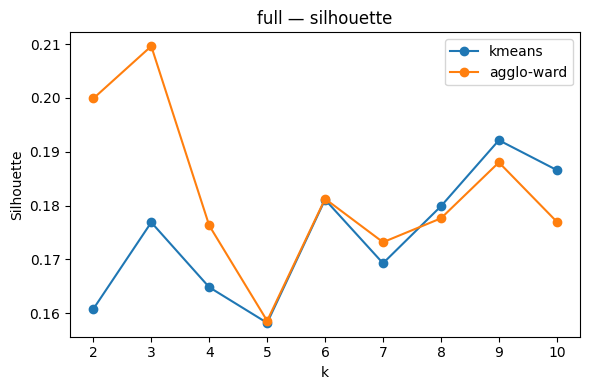

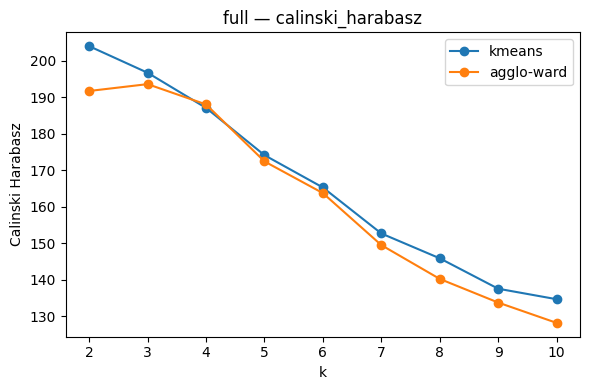

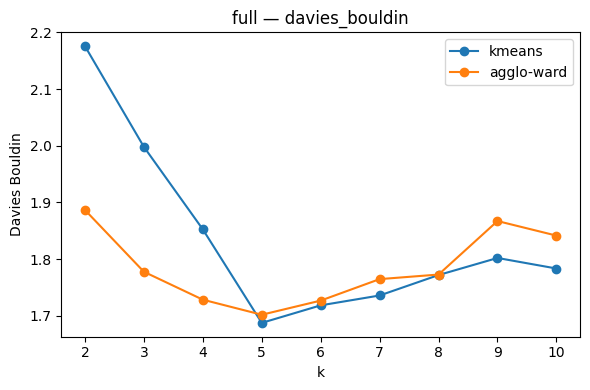

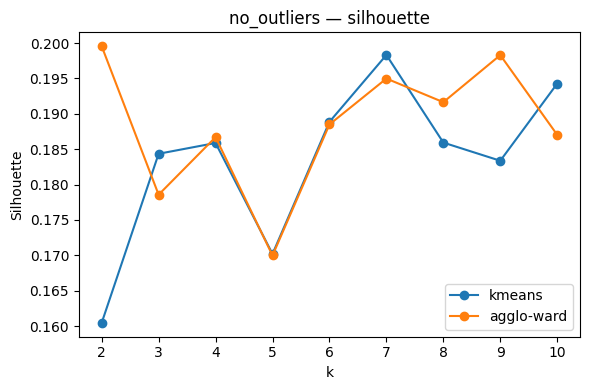

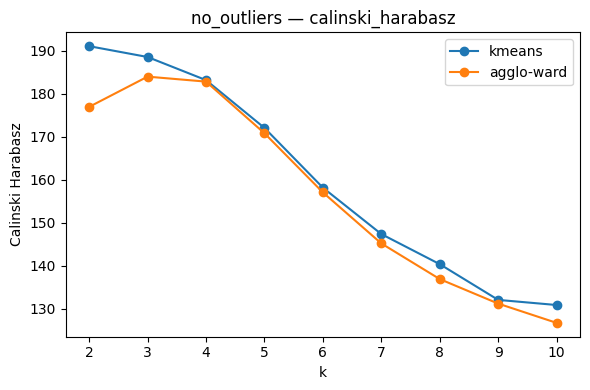

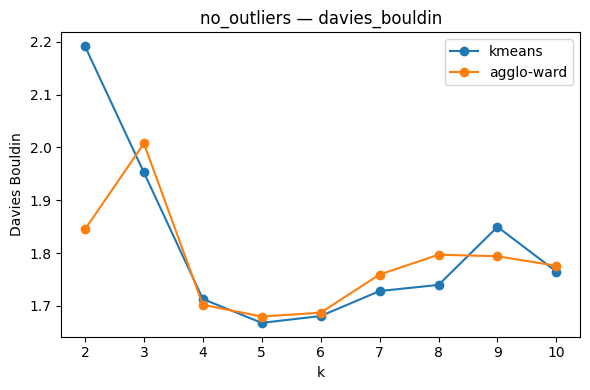

(algo                      agglo-ward
 k                                  3
 silhouette                  0.209632
 calinski_harabasz         193.647006
 davies_bouldin              1.777636
 silhouette_norm                  1.0
 calinski_harabasz_norm      0.862801
 davies_bouldin_norm         0.815295
 composite                   0.892699
 Name: 10, dtype: object,
 algo                      agglo-ward
 k                                  4
 silhouette                  0.186699
 calinski_harabasz         182.806737
 davies_bouldin              1.701993
 silhouette_norm             0.671275
 calinski_harabasz_norm      0.871885
 davies_bouldin_norm         0.934611
 composite                   0.825924
 Name: 11, dtype: object)

In [76]:
k_values = range(2, 11)

results = {}
for label, bundle in DATASETS.items():
    X = bundle["pca90"][Xcols_full if label=="full" else Xcols_noout].values
    df_km   = evaluate_kmeans(X, k_values)
    df_ag   = evaluate_agglo(X, k_values, linkage="ward")
    scores  = pd.concat([df_km, df_ag], ignore_index=True)
    best, scored = pick_best_row(scores)
    results[label] = {"scores": scored, "best": best}

    # Quick plot
    for metric in ["silhouette", "calinski_harabasz", "davies_bouldin"]:
        plt.figure(figsize=(6,4))
        for algo in scored["algo"].unique():
            sub = scored[scored["algo"]==algo]
            plt.plot(sub["k"], sub[metric], marker="o", label=algo)
        plt.xlabel("k"); plt.ylabel(metric.replace("_"," ").title()); plt.title(f"{label} — {metric}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_PATH / f"{label}_{metric}.png", dpi=140)
        plt.show()

results["full"]["best"], results["no_outliers"]["best"]


In [77]:
def scan_dbscan(X, min_samples=10, q_list=(85, 90, 92, 94, 95, 96, 97, 98)):
    # k-distance heuristic via pairwise distances to min_samples-th neighbor is expensive; keep simple:
    # We'll scan eps via quantiles of pairwise distances on a sample.
    from sklearn.neighbors import NearestNeighbors
    n = len(X)
    take = min(1500, n)
    idx = np.random.choice(n, take, replace=False)
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X[idx])
    dists, _ = nbrs.kneighbors(X[idx])
    kth = np.sort(dists[:, -1])
    rows=[]
    for q in q_list:
        eps = float(np.quantile(kth, q/100))
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)
        ncl = len(set(labels)) - (1 if -1 in labels else 0)
        noise = int((labels==-1).sum())
        sil = np.nan
        if ncl >= 2:
            # silhouette can't handle noise directly; filter noise
            mask = labels != -1
            if mask.sum()>0 and len(np.unique(labels[mask]))>=2:
                sil = silhouette_score(X[mask], labels[mask])
        rows.append({"q":q, "eps":eps, "clusters":ncl, "noise":noise, "silhouette":sil})
    return pd.DataFrame(rows)

dbscan_summaries = {}
for label, bundle in DATASETS.items():
    X = bundle["pca90"][Xcols_full if label=="full" else Xcols_noout].values
    dbscan_summaries[label] = scan_dbscan(X)

dbscan_summaries["full"], dbscan_summaries["no_outliers"]


(    q       eps  clusters  noise  silhouette
 0  85  0.805357         4     19    0.212617
 1  90  0.844152         4     10    0.212869
 2  92  0.871901         4      8    0.212459
 3  94  0.895619         4      7    0.212748
 4  95  0.907379         4      4    0.212963
 5  96  0.924991         4      1    0.213108
 6  97  0.954138         3      1    0.157805
 7  98  0.971146         2      0    0.199907,
     q       eps  clusters  noise  silhouette
 0  85  0.791685         4      9    0.212010
 1  90  0.828491         4      5    0.211915
 2  92  0.846770         4      4    0.211988
 3  94  0.876169         4      2    0.211920
 4  95  0.885329         4      2    0.211920
 5  96  0.897990         4      2    0.211920
 6  97  0.916422         4      2    0.211920
 7  98  0.942335         4      0    0.212258)

In [61]:
def fit_final_models(X, best_row):
    algo = best_row["algo"]
    k    = int(best_row["k"])
    if algo == "kmeans":
        model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
        labels = model.fit_predict(X)
    elif algo.startswith("agglo"):
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(X)
    else:
        raise ValueError("Unsupported algo for final fit.")
    return model, labels

final = {}
for label, bundle in DATASETS.items():
    X = bundle["pca90"][Xcols_full if label=="full" else Xcols_noout].values
    best = results[label]["best"]
    model, labels = fit_final_models(X, best)
    DATASETS[label]["final_labels"] = pd.DataFrame({"row_id": bundle["pca90"]["row_id"], "cluster": labels})
    final[label] = {"model": model, "labels": labels, "best": best}

final["full"]["best"], final["no_outliers"]["best"]


(algo                      agglo-ward
 k                                  3
 silhouette                  0.209632
 calinski_harabasz         193.647006
 davies_bouldin              1.777636
 silhouette_norm                  1.0
 calinski_harabasz_norm      0.862801
 davies_bouldin_norm         0.818299
 composite                     0.8937
 Name: 10, dtype: object,
 algo                      agglo-ward
 k                                  4
 silhouette                  0.186699
 calinski_harabasz         182.806737
 davies_bouldin              1.701993
 silhouette_norm             0.671275
 calinski_harabasz_norm      0.871885
 davies_bouldin_norm         0.934611
 composite                   0.825924
 Name: 11, dtype: object)

In [63]:
def attach_and_save(label, out_name):
    b = DATASETS[label]
    lbl = b["final_labels"]
    # Join labels to each projection and descriptives
    out = {}
    for key in ["pca90","pca2d","tsne2d","umap2d","desc"]:
        df = b[key].merge(lbl, on="row_id", how="left")
        out[key] = df

    # Save tidy Excel with multiple sheets
    path = OUT_PATH / out_name
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        out["pca90"].to_excel(writer, sheet_name="pca90_with_clusters", index=False)
        out["pca2d"].to_excel(writer, sheet_name="pca2d_with_clusters", index=False)
        out["tsne2d"].to_excel(writer, sheet_name="tsne2d_with_clusters", index=False)
        out["umap2d"].to_excel(writer, sheet_name="umap2d_with_clusters", index=False)
        out["desc"].to_excel(writer, sheet_name="descriptive_with_clusters", index=False)
    return path, out

path_full,      joined_full      = attach_and_save("full",        "03_climate_dataset_clustered.xlsx")
path_noout,     joined_noout     = attach_and_save("no_outliers", "03_climate_dataset_clustered_noOutliers.xlsx")
path_full, path_noout


(WindowsPath('C:/Users/Vaccari/Desktop/iCloudDrive/Desktop/ENRICO/05_LEARNING/University/ToU/Phases/02_Calibration_Phase/Applied_Machine_Learning/Clustering/Mapping_The_Italian_Climate_Mindscape/data/processed/03_climate_dataset_clustered.xlsx'),
 WindowsPath('C:/Users/Vaccari/Desktop/iCloudDrive/Desktop/ENRICO/05_LEARNING/University/ToU/Phases/02_Calibration_Phase/Applied_Machine_Learning/Clustering/Mapping_The_Italian_Climate_Mindscape/data/processed/03_climate_dataset_clustered_noOutliers.xlsx'))

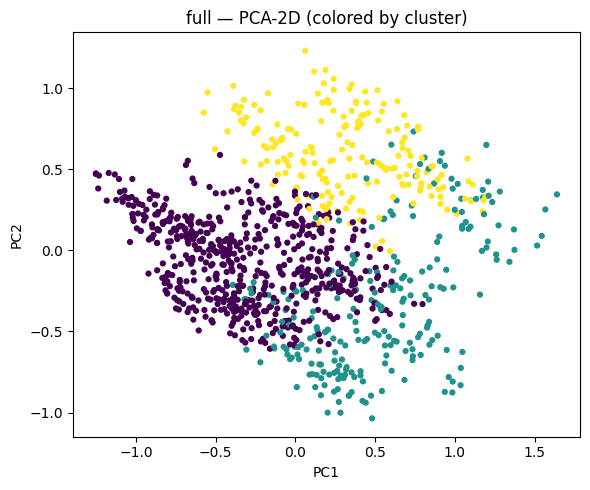

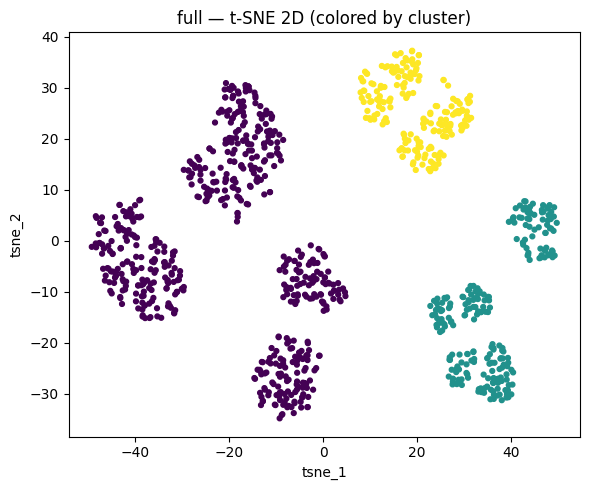

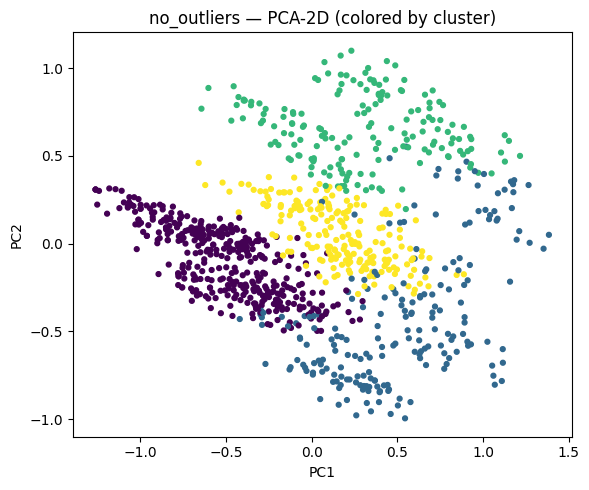

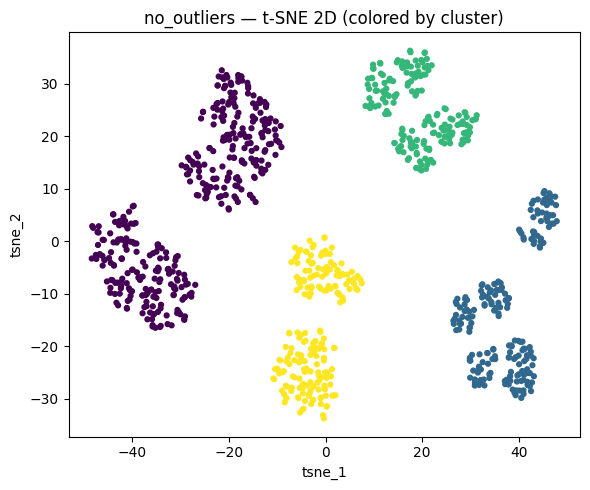

In [64]:
def scatter2d(df, x, y, c, title):
    plt.figure(figsize=(6,5))
    plt.scatter(df[x], df[y], c=df[c], s=12)
    plt.title(title); plt.xlabel(x); plt.ylabel(y)
    plt.tight_layout()
    plt.show()

# Try common names; fall back to first two numeric cols
def guess_xy(df):
    cols = numeric_cols(df)
    x = next((c for c in cols if c.lower() in ["pc1","pca1","dim1","x"]), cols[1])
    y = next((c for c in cols if c.lower() in ["pc2","pca2","dim2","y"]), cols[2])
    return x, y

for label, joined in [("full", joined_full), ("no_outliers", joined_noout)]:
    # PCA-2D
    x, y = guess_xy(joined["pca2d"])
    scatter2d(joined["pca2d"], x, y, "cluster", f"{label} — PCA-2D (colored by cluster)")
    # t-SNE
    x2, y2 = guess_xy(joined["tsne2d"])
    scatter2d(joined["tsne2d"], x2, y2, "cluster", f"{label} — t-SNE 2D (colored by cluster)")


In [68]:
import numpy as np
import pandas as pd

def top_numeric_effects(desc_with_labels, top_k=8):
    df = desc_with_labels.copy()
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["row_id","cluster"]]
    out = []
    overall_mean = df[num_cols].mean()
    overall_std  = df[num_cols].std(ddof=0).replace(0, np.nan)

    for cl, g in df.groupby("cluster"):
        delta = (g[num_cols].mean() - overall_mean) / overall_std
        # Long form with absolute rank for picking top K
        tmp = (delta
               .to_frame("smd")  # standardized mean difference (≈ Cohen’s d)
               .assign(cluster=cl,
                       rank_abs=lambda d: d["smd"].abs().rank(ascending=False),
                       sign=lambda d: np.sign(d["smd"]).astype(int))
               .sort_values("rank_abs")
              )
        out.append(tmp)
    eff = pd.concat(out, axis=0, ignore_index=False).reset_index(names="feature")
    # nicer sort within each cluster
    eff["abs_smd"] = eff["smd"].abs()
    return eff.sort_values(["cluster","abs_smd"], ascending=[True, False])

def top_categorical_lifts(desc_with_labels, top_k=8, min_prop=0.03):
    df = desc_with_labels.copy()
    cat_cols = df.select_dtypes(include=["object","category","bool"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c not in ["row_id","cluster"]]
    out = []
    for c in cat_cols:
        base = df[c].value_counts(normalize=True)
        # skip columns that are almost unique or empty
        if base.empty: 
            continue
        for cl, g in df.groupby("cluster"):
            p = g[c].value_counts(normalize=True)
            joined = (pd.DataFrame({"overall": base})
                        .join(pd.DataFrame({"cluster": p}), how="outer")
                        .fillna(0.0)
                        .assign(feature=c, cluster=cl)
                        .reset_index(names="level"))
            joined["lift"] = np.where(joined["overall"]>0, joined["cluster"]/joined["overall"], np.nan)
            joined["delta"] = joined["cluster"] - joined["overall"]
            # keep only levels that appear at least a bit
            joined = joined[(joined["cluster"] >= min_prop) | (joined["overall"] >= min_prop)]
            out.append(joined)
    if not out:
        return pd.DataFrame(columns=["feature","level","cluster","overall","lift","delta"])
    lifts = pd.concat(out, ignore_index=True)
    # rank by absolute delta first, then lift distance from 1
    lifts["abs_delta"] = lifts["delta"].abs()
    lifts["lift_dev"]  = (lifts["lift"] - 1).abs()
    lifts = lifts.sort_values(["cluster","abs_delta","lift_dev"], ascending=[True, False, False])
    return lifts

# Build profiles for FULL and NO-OUTLIERS descriptive frames you already saved in `joined_full` / `joined_noout`
# --- replace ONLY the "Compact top K per cluster" block from before with this ---
for label, joined in [("full", joined_full), ("no_outliers", joined_noout)]:
    descL = joined["desc"].copy()
    num_eff   = top_numeric_effects(descL)
    cat_lifts = top_categorical_lifts(descL)

    # Save full tables
    num_eff.to_excel(OUT_PATH / f"06_{label}_top_numeric_effects.xlsx", index=False)
    cat_lifts.to_excel(OUT_PATH / f"06_{label}_top_categorical_lifts.xlsx", index=False)

    # ---- TopK NUMERIC
    topk_num = (num_eff
                .groupby("cluster", group_keys=False)
                .apply(lambda d: d.nlargest(8, "abs_smd"))[["feature","smd","abs_smd","sign"]]
                .reset_index())

    # ---- TopK CATEGORICAL (guard empty)
    if cat_lifts.empty or "abs_delta" not in cat_lifts.columns or "lift_dev" not in cat_lifts.columns:
        topk_cat = pd.DataFrame(columns=["cluster","feature","level","overall","cluster_prop","delta","lift"])
    else:
        tmp = (cat_lifts
               .rename(columns={"cluster":"cluster_id"})  # avoid confusion in selection
               .sort_values(["cluster_id","abs_delta","lift_dev"], ascending=[True, False, False])
               .groupby("cluster_id", group_keys=False)
               .apply(lambda d: d.head(12))
               .reset_index(drop=True))
        topk_cat = tmp.rename(columns={"cluster_id":"cluster", "cluster":"cluster_prop"})[
            ["cluster","feature","level","overall","cluster_prop","delta","lift"]
        ]

    topk_num.to_excel(OUT_PATH / f"06_{label}_TOPNUM.xlsx", index=False)
    topk_cat.to_excel(OUT_PATH / f"06_{label}_TOPCAT.xlsx", index=False)

print("Patched: saved 06_* profiles and TOP tables.")

Patched: saved 06_* profiles and TOP tables.


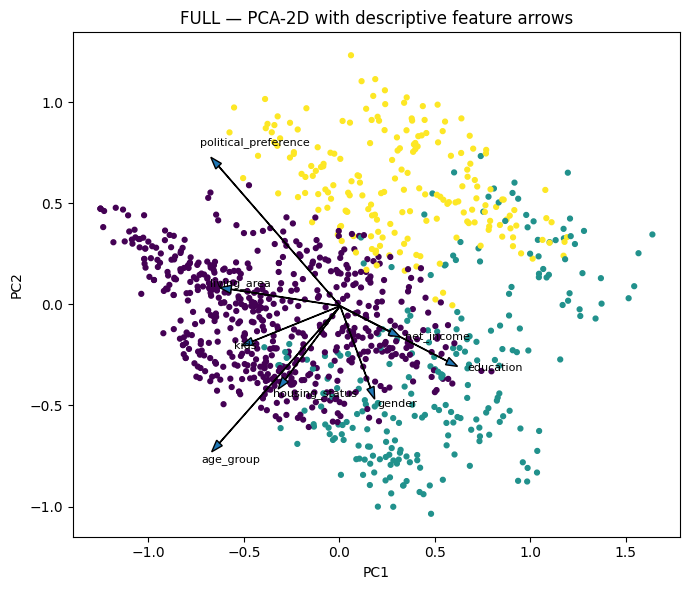

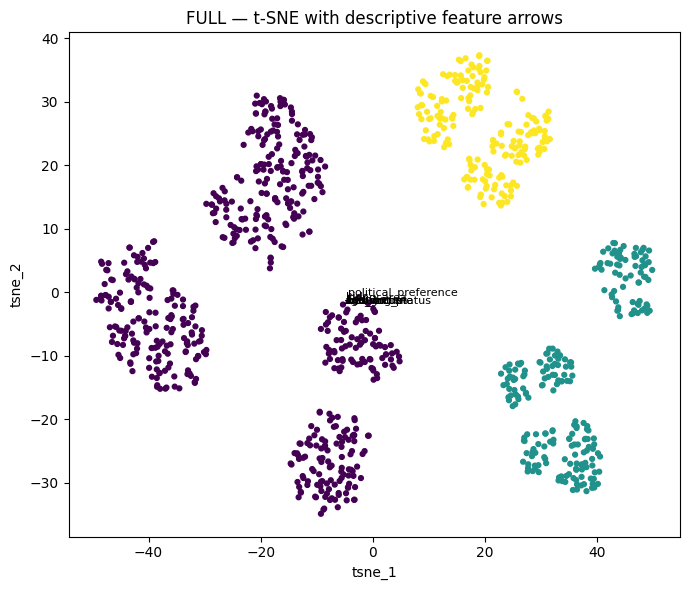

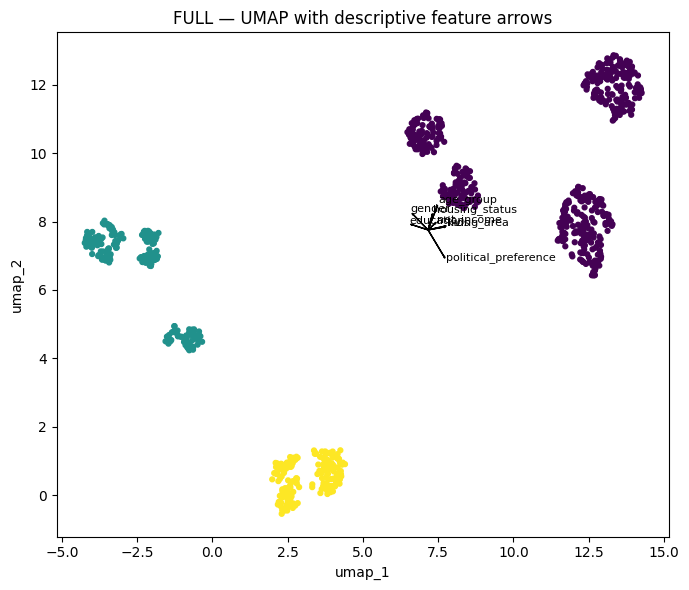

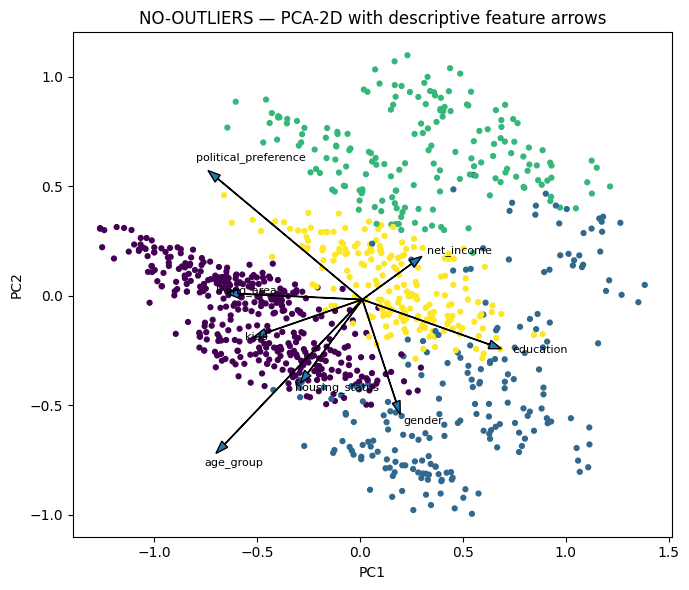

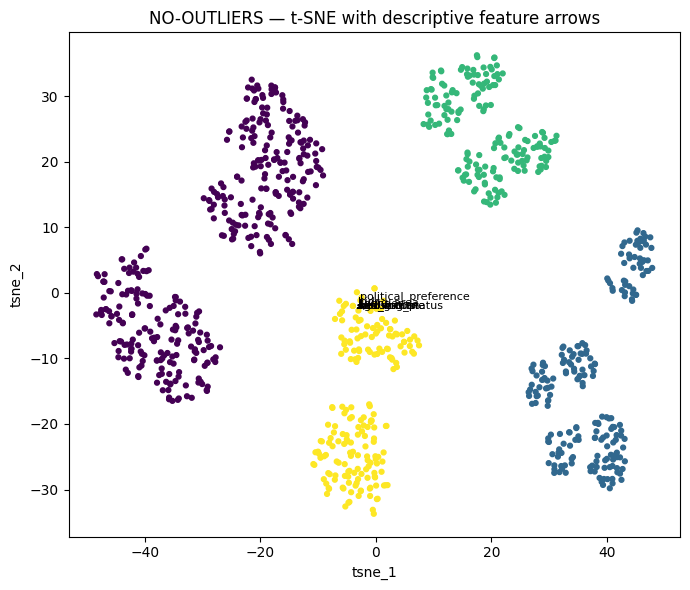

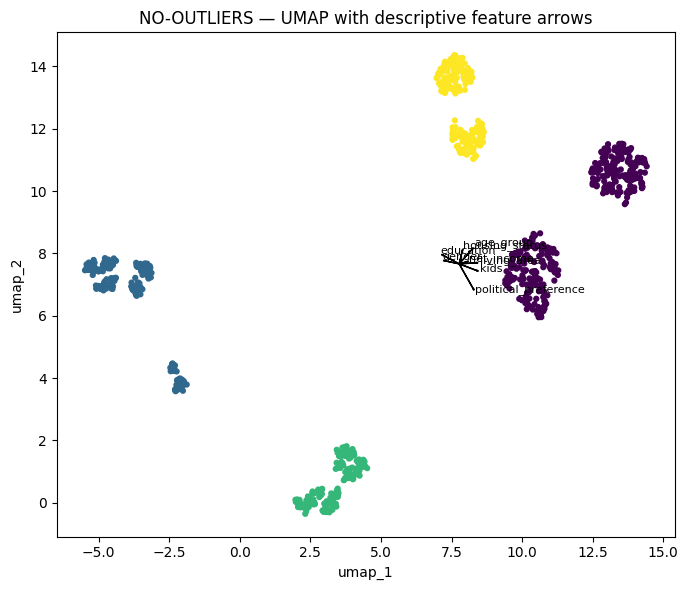

In [66]:
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

def _get_xy_cols(df):
    # Try common names, else first two numeric columns after row_id/cluster
    cand = [c.lower() for c in df.columns]
    name_map = {c.lower(): c for c in df.columns}
    for a,b in [("pc1","pc2"), ("pca1","pca2"), ("dim1","dim2"), ("x","y")]:
        if a in cand and b in cand:
            return name_map[a], name_map[b]
    cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["row_id","cluster"]]
    return cols[0], cols[1]

def compute_feature_vectors(embed_df, feature_df, feature_cols, center=True):
    """
    Regress each feature on [x, y] to get a direction vector (βx, βy).
    Returns a tidy DataFrame with scaled vectors and raw betas.
    """
    df = embed_df.merge(feature_df[["row_id"]+feature_cols], on="row_id", how="inner").dropna()
    xcol, ycol = _get_xy_cols(df)
    X = df[[xcol, ycol]].values
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    # add intercept
    Z = np.c_[X, np.ones(len(X))]

    rows = []
    for f in feature_cols:
        y = df[f].values
        # standardize y → comparable arrow lengths
        y = (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)
        beta, *_ = lstsq(Z, y, rcond=None)  # [bx, by, b0]
        rows.append({"feature": f, "beta_x": beta[0], "beta_y": beta[1]})
    vecs = pd.DataFrame(rows)

    # Scale vectors to a reasonable length range for plotting
    vecs["length"] = np.sqrt(vecs["beta_x"]**2 + vecs["beta_y"]**2)
    if (vecs["length"] > 0).any():
        # normalize to [0,1] then rescale
        ln = vecs["length"]
        vecs["scale"] = (ln - ln.min()) / (ln.max() - ln.min() + 1e-12)
        vecs["plot_len"] = 0.35 + 0.65*vecs["scale"]  # feel free to tweak
        # unit direction
        ux = vecs["beta_x"] / (ln + 1e-12)
        uy = vecs["beta_y"] / (ln + 1e-12)
        vecs["vx"] = ux * vecs["plot_len"]
        vecs["vy"] = uy * vecs["plot_len"]
    else:
        vecs["vx"] = 0.0; vecs["vy"] = 0.0; vecs["plot_len"] = 0.0
    return vecs, (xcol, ycol)

def plot_embedding_with_arrows(embed_df, feature_df, feature_cols, title, max_arrows=15, annotate=True):
    # Merge labels for coloring
    df = embed_df.merge(feature_df[["row_id"]], on="row_id", how="inner")
    xcol, ycol = _get_xy_cols(df)
    # Color by cluster if present
    colors = df["cluster"] if "cluster" in df.columns else None

    vecs, (xcol, ycol) = compute_feature_vectors(df, feature_df, feature_cols)
    # choose top by length
    vecs_plot = vecs.sort_values("plot_len", ascending=False).head(max_arrows)

    plt.figure(figsize=(7,6))
    plt.scatter(df[xcol], df[ycol], c=colors, s=12)
    # draw arrows from origin of the embedding (or median)
    x0, y0 = df[xcol].median(), df[ycol].median()
    for _, r in vecs_plot.iterrows():
        plt.arrow(x0, y0, r["vx"], r["vy"], width=0.002, head_width=0.04, length_includes_head=True)
        if annotate:
            plt.text(x0 + r["vx"]*1.08, y0 + r["vy"]*1.08, r["feature"], fontsize=8)
    plt.title(title); plt.xlabel(xcol); plt.ylabel(ycol)
    plt.tight_layout()
    plt.show()
    return vecs

# ---- Prepare the feature matrices ----
# 1) Original 12 clustering features (scaled) — provide these if not already loaded.
#    If you don't have variables yet, set them now (filenames are placeholders):
try:
    X12_full
except NameError:
    X12_full = None
try:
    X12_noout
except NameError:
    X12_noout = None

# 2) Descriptive numeric features (already in joined_*["desc"])
desc_num_full = joined_full["desc"].select_dtypes(include=np.number).copy()
desc_num_no   = joined_noout["desc"].select_dtypes(include=np.number).copy()
for d in (desc_num_full, desc_num_no):
    # keep row_id + numeric (drop cluster here; it will come from the embedding side)
    keep = ["row_id"] + [c for c in d.columns if c not in ["cluster"]]
    d.drop(columns=[c for c in d.columns if c not in keep], inplace=True, errors="ignore")

# ---- Run for FULL ----
# PCA-2D arrows
desc_vecs_full_pca = plot_embedding_with_arrows(joined_full["pca2d"], desc_num_full,
                                                [c for c in desc_num_full.columns if c != "row_id"],
                                                title="FULL — PCA-2D with descriptive feature arrows",
                                                max_arrows=20)

# t-SNE arrows
desc_vecs_full_tsne = plot_embedding_with_arrows(joined_full["tsne2d"], desc_num_full,
                                                 [c for c in desc_num_full.columns if c != "row_id"],
                                                 title="FULL — t-SNE with descriptive feature arrows",
                                                 max_arrows=20)

# UMAP arrows (optional)
desc_vecs_full_umap = plot_embedding_with_arrows(joined_full["umap2d"], desc_num_full,
                                                 [c for c in desc_num_full.columns if c != "row_id"],
                                                 title="FULL — UMAP with descriptive feature arrows",
                                                 max_arrows=20)

# Original 12 clustering features (if provided)
if X12_full is not None:
    X12_cols_full = [c for c in X12_full.select_dtypes(include=np.number).columns if c != "row_id"]
    _ = plot_embedding_with_arrows(joined_full["pca2d"], X12_full, X12_cols_full,
                                   title="FULL — PCA-2D with 12 clustering feature arrows",
                                   max_arrows=min(12, len(X12_cols_full)))
    _ = plot_embedding_with_arrows(joined_full["tsne2d"], X12_full, X12_cols_full,
                                   title="FULL — t-SNE with 12 clustering feature arrows",
                                   max_arrows=min(12, len(X12_cols_full)))

# ---- Run for NO-OUTLIERS ----
desc_vecs_no_pca = plot_embedding_with_arrows(joined_noout["pca2d"], desc_num_no,
                                              [c for c in desc_num_no.columns if c != "row_id"],
                                              title="NO-OUTLIERS — PCA-2D with descriptive feature arrows",
                                              max_arrows=20)

desc_vecs_no_tsne = plot_embedding_with_arrows(joined_noout["tsne2d"], desc_num_no,
                                               [c for c in desc_num_no.columns if c != "row_id"],
                                               title="NO-OUTLIERS — t-SNE with descriptive feature arrows",
                                               max_arrows=20)

desc_vecs_no_umap = plot_embedding_with_arrows(joined_noout["umap2d"], desc_num_no,
                                               [c for c in desc_num_no.columns if c != "row_id"],
                                               title="NO-OUTLIERS — UMAP with descriptive feature arrows",
                                               max_arrows=20)

if X12_noout is not None:
    X12_cols_no = [c for c in X12_noout.select_dtypes(include=np.number).columns if c != "row_id"]
    _ = plot_embedding_with_arrows(joined_noout["pca2d"], X12_noout, X12_cols_no,
                                   title="NO-OUTLIERS — PCA-2D with 12 clustering feature arrows",
                                   max_arrows=min(12, len(X12_cols_no)))
    _ = plot_embedding_with_arrows(joined_noout["tsne2d"], X12_noout, X12_cols_no,
                                   title="NO-OUTLIERS — t-SNE with 12 clustering feature arrows",
                                   max_arrows=min(12, len(X12_cols_no)))


In [69]:
# ---- helpers
def top3_numeric_per_cluster(desc_with_labels):
    df = desc_with_labels.copy()
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in ["row_id","cluster"]]
    overall_mean = df[num_cols].mean()
    overall_std  = df[num_cols].std(ddof=0).replace(0, np.nan)

    rows = []
    for cl, g in df.groupby("cluster"):
        smd = ((g[num_cols].mean() - overall_mean) / overall_std).to_frame("smd").reset_index()
        smd["abs_smd"] = smd["smd"].abs()
        top3 = smd.nlargest(3, "abs_smd")
        top3["cluster"] = cl
        rows.append(top3.rename(columns={"index":"feature"}))
    return pd.concat(rows, ignore_index=True)

def ensure_scaled12_loaded():
    # Expect variables in memory; otherwise try simple Excel loaders.
    global full_scaled, noout_scaled
    if "full_scaled" not in globals() or full_scaled is None:
        try:
            full_scaled = pd.read_excel(PROCESSED_PATH / "full_scaled.xlsx", sheet_name="Sheet1")
        except Exception:
            full_scaled = None
    if "noout_scaled" not in globals() or noout_scaled is None:
        try:
            noout_scaled = pd.read_excel(PROCESSED_PATH / "noout_scaled.xlsx", sheet_name="Sheet1")
        except Exception:
            noout_scaled = None

    # Make sure row_id exists
    for df in [full_scaled, noout_scaled]:
        if df is not None and "row_id" not in df.columns:
            df.insert(0, "row_id", np.arange(len(df)))

def top3_from_scaled12(joined_proj_df, scaled12_df):
    """joined_proj_df is e.g., joined_full['pca90'] (has row_id + cluster).
       scaled12_df must have row_id + the 12 scaled features."""
    if scaled12_df is None:
        return pd.DataFrame(columns=["cluster","feature","smd","abs_smd"])
    merged = (joined_proj_df[["row_id","cluster"]]
              .merge(scaled12_df, on="row_id", how="left"))
    return top3_numeric_per_cluster(merged)

# ---- compute for FULL / NO-OUTLIERS
ensure_scaled12_loaded()

summaries = {}
for label, joined in [("full", joined_full), ("no_outliers", joined_noout)]:
    # 3 best from original scaled clustering features (12D)
    if label == "full":
        top3_clust = top3_from_scaled12(joined["pca90"], full_scaled)
    else:
        top3_clust = top3_from_scaled12(joined["pca90"], noout_scaled)

    # 3 best from DESCRIPTIVE numerics
    top3_desc  = top3_numeric_per_cluster(joined["desc"])

    # pack a neat table: three + three per cluster
    def pack_table(t3c, t3d):
        # rank within cluster
        t3c = (t3c.sort_values(["cluster","abs_smd"], ascending=[True, False])
                  .groupby("cluster")
                  .apply(lambda d: d.head(3))
                  .reset_index(drop=True)
                  .assign(source="clustering_12"))
        t3d = (t3d.sort_values(["cluster","abs_smd"], ascending=[True, False])
                  .groupby("cluster")
                  .apply(lambda d: d.head(3))
                  .reset_index(drop=True)
                  .assign(source="descriptive_num"))
        out = (pd.concat([t3c, t3d], ignore_index=True)
                 [["cluster","source","feature","smd","abs_smd"]]
                 .sort_values(["cluster","source","abs_smd"], ascending=[True, True, False]))
        # nicer order: put clustering_12 first within each cluster
        out["source"] = pd.Categorical(out["source"], ["clustering_12","descriptive_num"])
        return out.sort_values(["cluster","source","abs_smd"], ascending=[True, True, False])

    summary = pack_table(top3_clust, top3_desc)
    path = OUT_PATH / f"07_{label}_TOP3_contributors.xlsx"
    summary.to_excel(path, index=False)
    summaries[label] = summary
    display(summary)


,cluster,source,feature,smd,abs_smd
0,0,clustering_12,flood_experience,-0.597151,0.597151
1,0,clustering_12,health_consequences,-0.552901,0.552901
2,0,clustering_12,climate_event_count,-0.386033,0.386033
9,0,descriptive_num,age_group,0.103014,0.103014
10,0,descriptive_num,living_area,0.088209,0.088209
11,0,descriptive_num,education,-0.062237,0.062237
3,1,clustering_12,health_consequences,1.808642,1.808642
4,1,clustering_12,climate_consequence_count,0.738899,0.738899
5,1,clustering_12,heat_experience,0.447907,0.447907
12,1,descriptive_num,gender,0.230344,0.230344


,cluster,source,feature,smd,abs_smd
0,0,descriptive_num,age_group,0.150267,0.150267
1,0,descriptive_num,living_area,0.140555,0.140555
2,0,descriptive_num,kids,0.136818,0.136818
3,1,descriptive_num,gender,0.230794,0.230794
4,1,descriptive_num,living_area,-0.170249,0.170249
5,1,descriptive_num,education,0.163764,0.163764
6,2,descriptive_num,age_group,-0.144870,0.144870
7,2,descriptive_num,gender,-0.097447,0.097447
8,2,descriptive_num,living_area,-0.095005,0.095005
9,3,descriptive_num,gender,-0.164644,0.164644


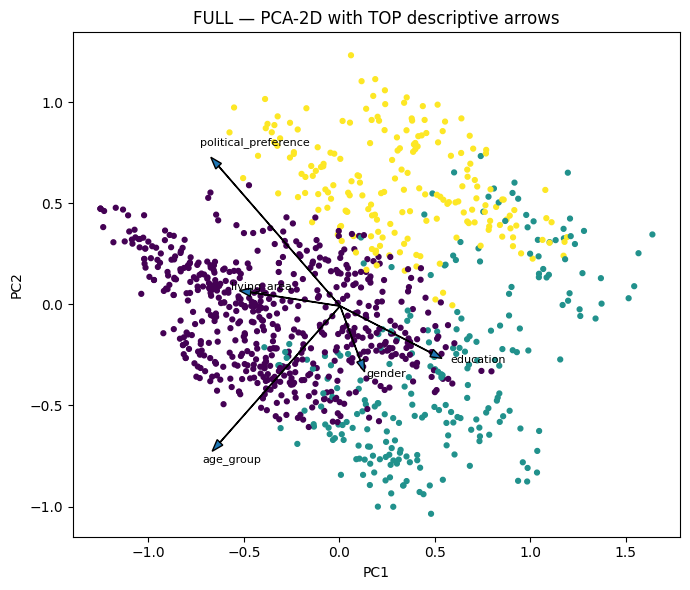

In [70]:
# Example for FULL on PCA-2D using the top features only
top_feats_full = (summaries["full"]
                  .query("source == 'descriptive_num'")
                  .feature.unique().tolist())

desc_vecs_full_pca_top = plot_embedding_with_arrows(
    joined_full["pca2d"],
    desc_num_full,
    [c for c in top_feats_full if c in desc_num_full.columns and c != "row_id"],
    title="FULL — PCA-2D with TOP descriptive arrows",
    max_arrows=12
)
